# Customer Churn Prediction — IBM Telco Dataset



## Dataset
- **Source:** IBM Telco Customer Churn (Kaggle)
- **Size:** 7,043 customers, 21 features
- **Features:** Contract type, tenure, monthly charges, internet service, payment method, and more
- **Target:** `Churn` — Yes (1) or No (0)


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Step 1 — Load & Audit Data

In [68]:
# Load dataset (upload Telco-Customer-Churn.csv to Colab or mount Drive)
# Option A — direct upload:  df = pd.read_csv('Telco-Customer-Churn.csv')
# Option B — Google Drive:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")          # expect (7043, 21)
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True).round(3)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (7043, 21)

Column dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [69]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== UNIQUE VALUES (categorical cols) ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique")

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0

=== UNIQUE VALUES (categorical cols) ===
  customerID: 7043 unique
  gender: 2 unique
  Partner: 2 unique
  Dependents: 2 unique
  PhoneService: 2 unique
  MultipleLines: 3 unique
  InternetService: 3 unique
  OnlineSecurity: 3 unique
  OnlineBackup: 3 unique
  DeviceProtection: 3 unique
  TechSupport: 3 unique
  StreamingTV: 3 unique
  StreamingMovies: 3 unique
  Contract: 3 unique
  PaperlessBilling: 2 unique
  PaymentMethod: 4 unique
  TotalCharges: 6531 u

## Step 2 — Data Cleaning

In [70]:
# Fix TotalCharges — stored as object due to blank strings (hidden null issue)
print(f"TotalCharges dtype before: {df['TotalCharges'].dtype}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
null_count = df['TotalCharges'].isnull().sum()
print(f"Null TotalCharges found: {null_count}  (these are new customers with tenure=0)")
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print(f"TotalCharges dtype after: {df['TotalCharges'].dtype}")

# Drop customerID — not a predictive feature
df.drop(columns=['customerID'], inplace=True)

# Verify no remaining nulls
print(f"\nRemaining nulls: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

TotalCharges dtype before: object
Null TotalCharges found: 11  (these are new customers with tenure=0)
TotalCharges dtype after: float64

Remaining nulls: 0
Final shape: (7043, 20)


/tmp/ipykernel_17123/1076105962.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


## Step 3 — Encoding Categorical Variables

In [71]:
# Step 3a: Binary Yes/No columns → 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Step 3b: Service columns with 'No internet service' / 'No phone service' → 0
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No internet service': 0, 'No phone service': 0})

# Step 3c: One-hot encode multi-class columns
df = pd.get_dummies(df,
                    columns=['gender', 'InternetService', 'Contract', 'PaymentMethod'],
                    drop_first=True)

print("Encoding complete.")
print(f"Shape after encoding: {df.shape}")
print(f"Remaining object cols: {df.select_dtypes(include='object').columns.tolist()}")

Encoding complete.
Shape after encoding: (7043, 24)
Remaining object cols: []


## Step 4 — Feature Engineering: TenureGroup

In [72]:
# Bin tenure into meaningful business segments
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['Short (0-12m)', 'Medium (13-36m)', 'Long (37-72m)']
)

# Check churn rate per group (key business insight before encoding)
print("Churn rate by tenure group:")
print(df.groupby('TenureGroup', observed=True)['Churn'].mean().round(3))

# One-hot encode TenureGroup
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

print(f"\nFinal shape: {df.shape}")
df.head(3)

Churn rate by tenure group:
TenureGroup
Short (0-12m)      0.477
Medium (13-36m)    0.255
Long (37-72m)      0.119
Name: Churn, dtype: float64

Final shape: (7043, 26)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Medium (13-36m),TenureGroup_Long (37-72m)
0,0,1,0,1,0,0,0,1,0,0,...,False,False,False,False,False,False,True,False,False,False
1,0,0,0,34,1,0,1,0,1,0,...,True,False,False,True,False,False,False,True,True,False
2,0,0,0,2,1,0,1,1,0,0,...,True,False,False,False,False,False,False,True,False,False


## Step 5 — Exploratory Data Analysis

8 visualisations covering churn distribution, key drivers, and correlations.

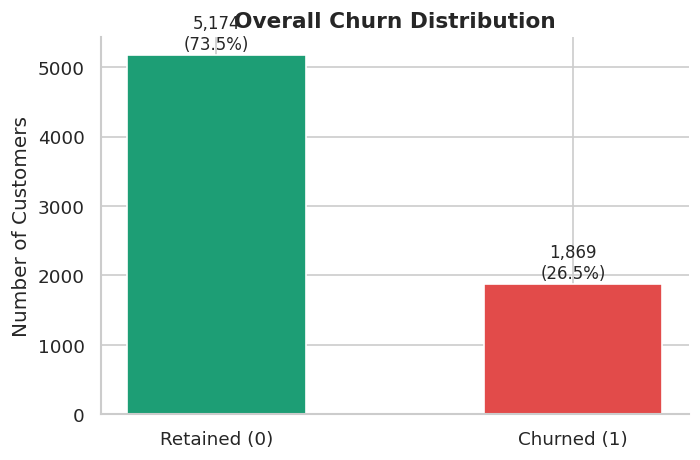

27% of customers churned — class imbalance present (73/27 split)


In [73]:
# ── Fig 1: Overall churn distribution ──────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#1D9E75', '#E24B4A']
counts = df['Churn'].value_counts()
bars = ax.bar(['Retained (0)', 'Churned (1)'], counts.values, color=colors, width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Overall Churn Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("27% of customers churned — class imbalance present (73/27 split)")

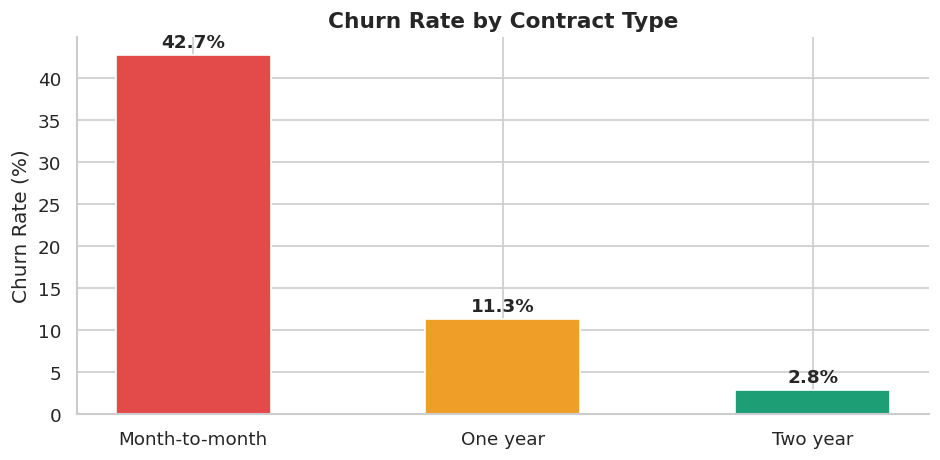

Month-to-month: ~42% churn | One year: ~11% | Two year: ~3%


In [74]:
# ── Fig 2: Churn rate by Contract type ─────────────────────
original_df = pd.read_csv('/content/drive/MyDrive/Telco-Customer-Churn.csv')
fig, ax = plt.subplots(figsize=(8, 4))
contract_churn = original_df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=['#E24B4A', '#EF9F27', '#1D9E75'], width=0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print("Month-to-month: ~42% churn | One year: ~11% | Two year: ~3%")

/tmp/ipykernel_17123/1614878255.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True, widths=0.4,


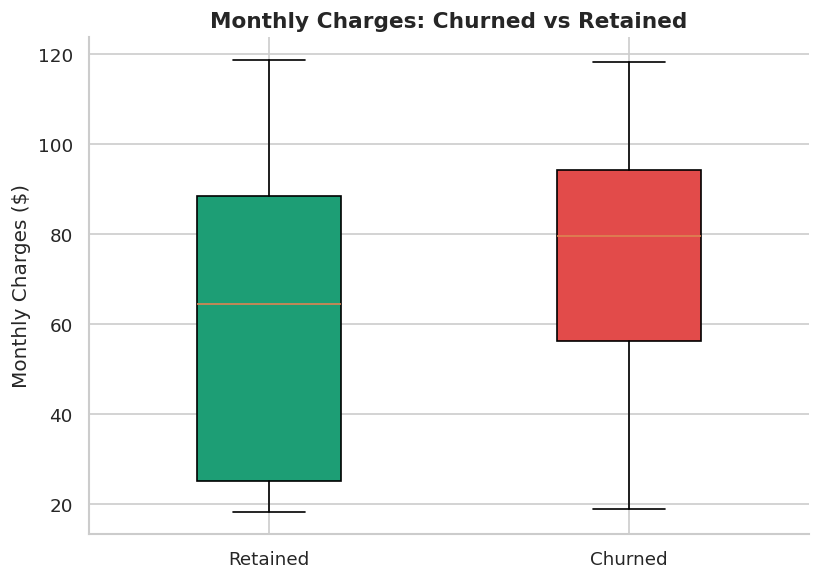

Churned customers median monthly charge: $79.65
Retained customers median monthly charge: $64.43


In [75]:
# ── Fig 3: Monthly charges boxplot (churned vs retained) ────
fig, ax = plt.subplots(figsize=(7, 5))
churn_labels = {0: 'Retained', 1: 'Churned'}
data_plot = [df[df['Churn']==0]['MonthlyCharges'],
             df[df['Churn']==1]['MonthlyCharges']]
bp = ax.boxplot(data_plot, patch_artist=True, widths=0.4,
                labels=['Retained', 'Churned'])
bp['boxes'][0].set_facecolor('#1D9E75')
bp['boxes'][1].set_facecolor('#E24B4A')
ax.set_title('Monthly Charges: Churned vs Retained', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Charges ($)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_monthly_charges_box.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Churned customers median monthly charge: ${df[df['Churn']==1]['MonthlyCharges'].median():.2f}")
print(f"Retained customers median monthly charge: ${df[df['Churn']==0]['MonthlyCharges'].median():.2f}")

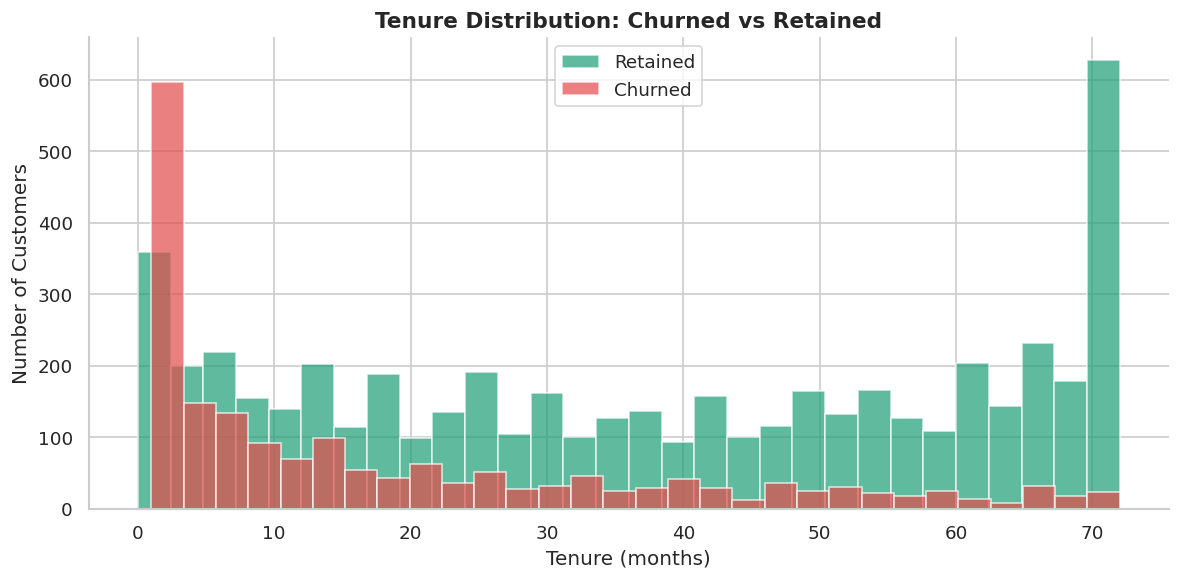

Churned customers avg tenure: 18.0 months
Retained customers avg tenure: 37.6 months


In [76]:
# ── Fig 4: Tenure histogram (churned vs retained) ───────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.7,
        label='Retained', color='#1D9E75', edgecolor='white')
ax.hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7,
        label='Churned', color='#E24B4A', edgecolor='white')
ax.set_title('Tenure Distribution: Churned vs Retained', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_tenure_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Churned customers avg tenure: {df[df['Churn']==1]['tenure'].mean():.1f} months")
print(f"Retained customers avg tenure: {df[df['Churn']==0]['tenure'].mean():.1f} months")

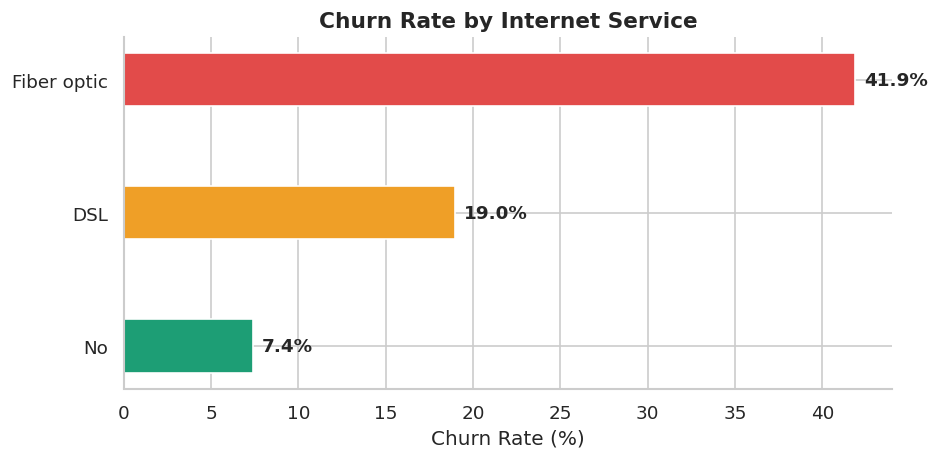

In [77]:
# ── Fig 5: Churn rate by Internet Service ───────────────────
fig, ax = plt.subplots(figsize=(8, 4))
internet_churn = original_df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).sort_values()
colors_map = ['#1D9E75', '#EF9F27', '#E24B4A']
bars = ax.barh(internet_churn.index, internet_churn.values,
               color=colors_map, height=0.4)
for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Internet Service', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_churn_internet.png', dpi=150, bbox_inches='tight')
plt.show()

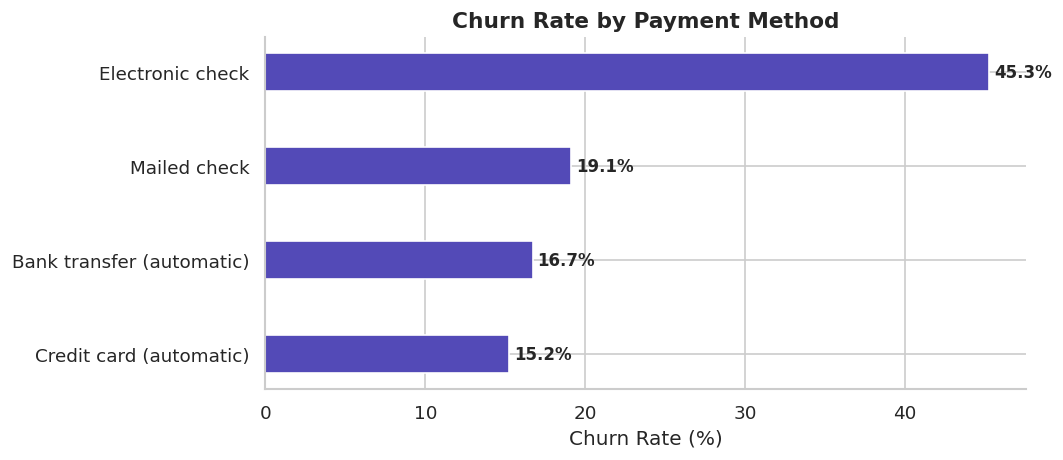

Electronic check has highest churn — autopay methods have lowest


In [78]:
# ── Fig 6: Churn rate by Payment Method ─────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
pay_churn = original_df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).sort_values()
bars = ax.barh(pay_churn.index, pay_churn.values, color='#534AB7', height=0.4)
for bar, val in zip(bars, pay_churn.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_churn_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Electronic check has highest churn — autopay methods have lowest")

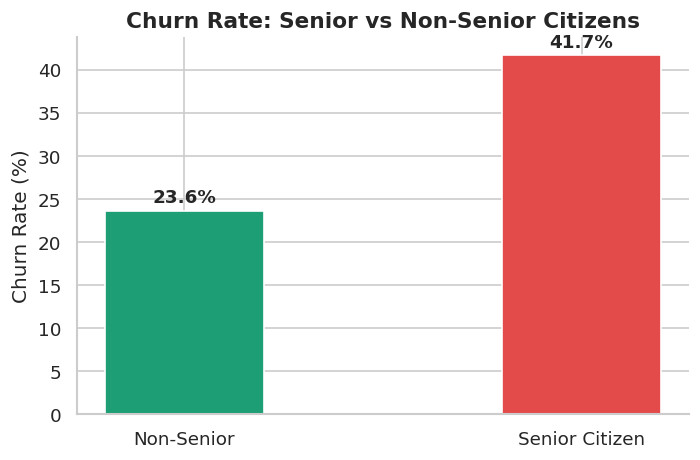

Senior citizen churn: 41.7% vs Non-senior: 23.6%


In [79]:
# ── Fig 7: Senior Citizen churn rate ────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
bars = ax.bar(['Non-Senior', 'Senior Citizen'], senior_churn.values,
              color=['#1D9E75', '#E24B4A'], width=0.4)
for bar, val in zip(bars, senior_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate: Senior vs Non-Senior Citizens', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig7_senior_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Senior citizen churn: {senior_churn[1]:.1f}% vs Non-senior: {senior_churn[0]:.1f}%")

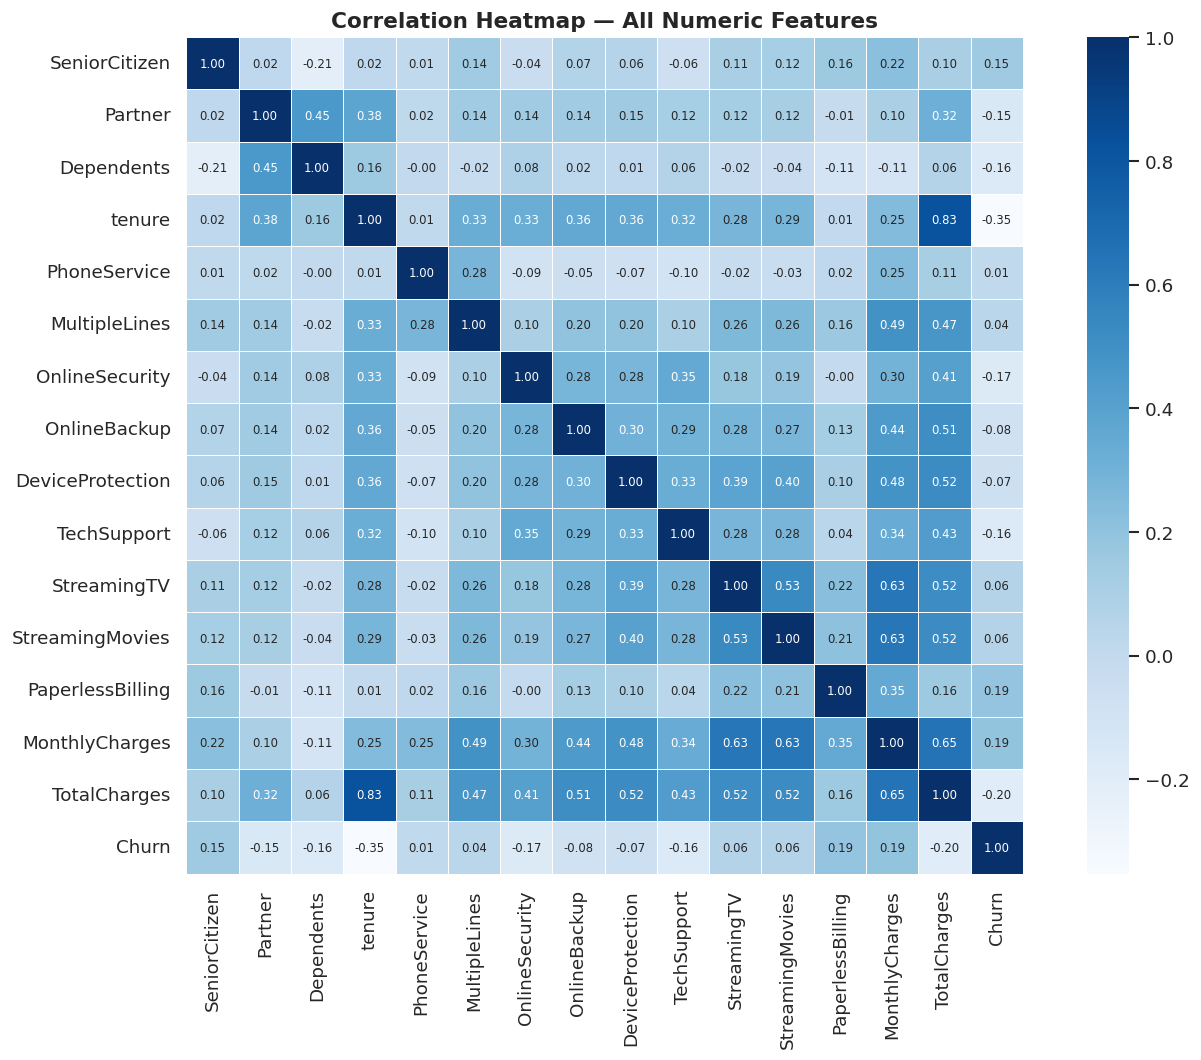

In [80]:
# ── Fig 8: Correlation heatmap (annot=True) ─────────────────
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — All Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Train / Test Split + Feature Scaling

In [81]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Features shape: (7043, 25)
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")

Train: 5634 rows | Test: 1409 rows
Train churn rate: 26.5% | Test: 26.5%


# Step 7 — RandomForest Model

In [83]:
# Step 2: Scale features
scaler = StandardScaler()
  # fit on train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)                # transform test

In [108]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=300,class_weight='balanced',max_depth=10,
    min_samples_leaf=2,random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=300, random_state=42)

## Step 8 — Model Evaluation

In [111]:
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
for t in [0.35, 0.4, 0.45]:
    y_pred = (y_pred_prob > t).astype(int)
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_prob):.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))


Accuracy:  75.9%
ROC-AUC:   0.845

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.75      0.82      1035
     Churned       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



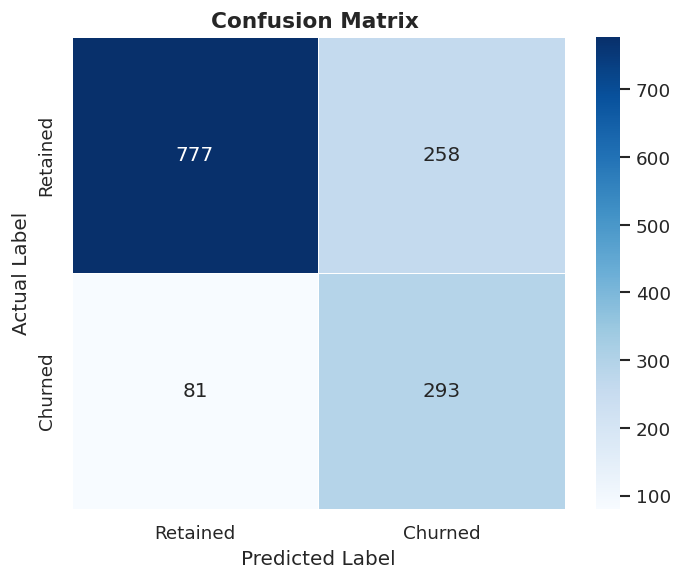

True Positives (correctly predicted churners): 293
False Negatives (missed churners):             81
False Positives (wrong churn alerts):          258


In [112]:
# ── Confusion matrix heatmap ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix ', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (correctly predicted churners): {tp}")
print(f"False Negatives (missed churners):             {fn}")
print(f"False Positives (wrong churn alerts):          {fp}")

In [113]:
import pandas as pd

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 important features:")
print(feat_df.head(10).to_string(index=False))

Top 10 important features:
                       Feature  Importance
                        tenure    0.163342
                MonthlyCharges    0.129079
                  TotalCharges    0.125710
             Contract_Two year    0.105316
   InternetService_Fiber optic    0.082213
PaymentMethod_Electronic check    0.055562
     TenureGroup_Long (37-72m)    0.044583
             Contract_One year    0.044038
            InternetService_No    0.037260
                OnlineSecurity    0.024817


## Step 9 — Feature Importance (Churn Drivers) Using Logistic Regression

# Logistic Regression


Gives:

1.   Positive → increases churn
2.   Negative → decreases churn

# Random Forest
Gives:

1.   Importance score only




In [114]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained successfully — no ConvergenceWarning with scaling applied")

Model trained successfully — no ConvergenceWarning with scaling applied


In [115]:
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 churn drivers (positive = increases churn risk):")
print(coef_df.head(10).to_string(index=False))
print()
print("Top 5 retention factors (negative = decreases churn risk):")
print(coef_df.tail(5).to_string(index=False))

Top 10 churn drivers (positive = increases churn risk):
                       Feature  Coefficient
   InternetService_Fiber optic     0.746962
               StreamingMovies     0.254269
     TenureGroup_Long (37-72m)     0.252467
                   StreamingTV     0.247771
                  TotalCharges     0.233254
                 MultipleLines     0.230220
              PaperlessBilling     0.185240
PaymentMethod_Electronic check     0.177028
                 SeniorCitizen     0.062297
              DeviceProtection     0.053610

Top 5 retention factors (negative = decreases churn risk):
           Feature  Coefficient
 Contract_One year    -0.295566
InternetService_No    -0.596317
 Contract_Two year    -0.608132
    MonthlyCharges    -0.759531
            tenure    -1.241702


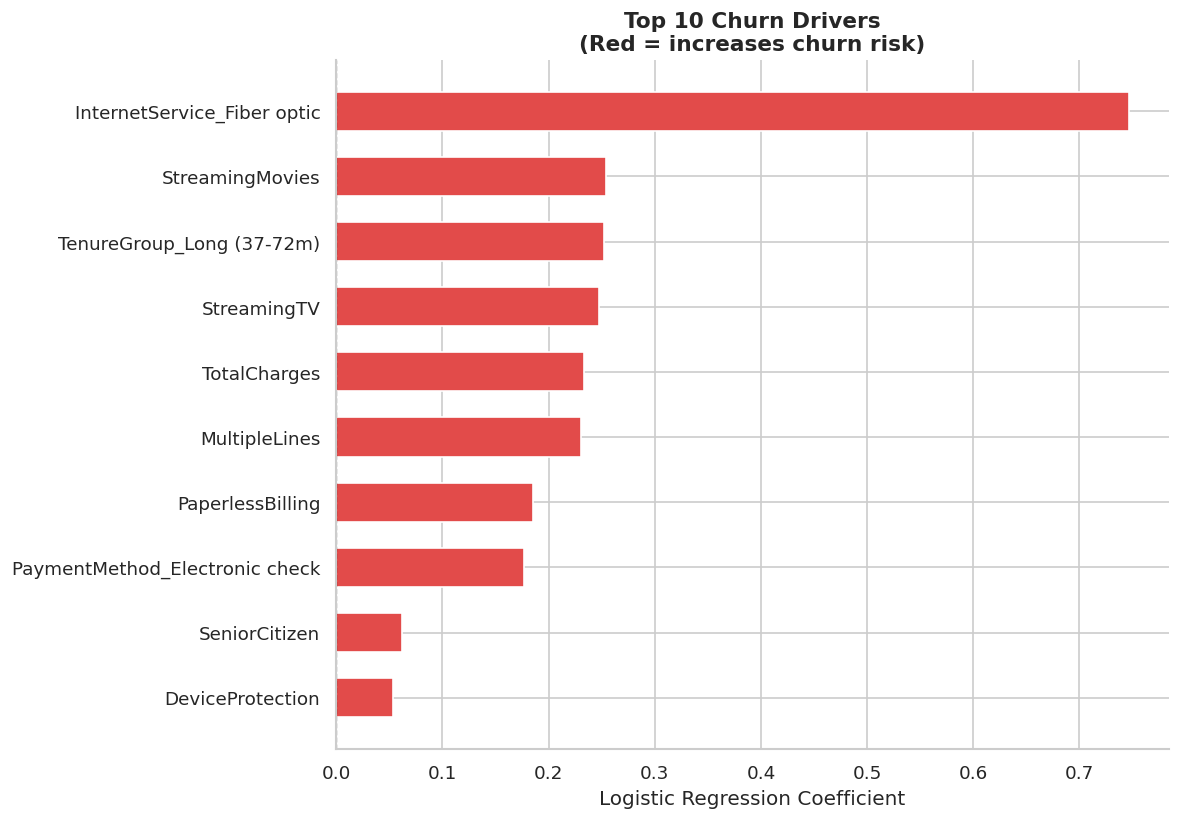

In [116]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(10, 7))
top10 = coef_df.head(10).sort_values('Coefficient')
colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in top10['Coefficient']]
bars = ax.barh(top10['Feature'], top10['Coefficient'], color=colors, height=0.6)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Top 10 Churn Drivers\n(Red = increases churn risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Logistic Regression Coefficient')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Key Findings**


1. *Month-to-month contracts have a ~42% churn rate vs ~11% for one-year and ~3% for two-year contracts*

2. *Short-tenure customers (0–12 months) are the highest-risk group — churn drops sharply after month 12*

3. *Fibre optic internet users churn more than DSL users (likely due to price sensitivity at higher plans)*

4. *Electronic check payment method has the highest churn; credit card (auto-pay) customers churn the least
Senior citizens churn at ~41% vs ~23% for non-senior customers*